# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [ ]:
# untuk plot Q-Q
import scipy.stats as stats

In [ ]:
df_california = pd.read_csv('california_dataset.csv')
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

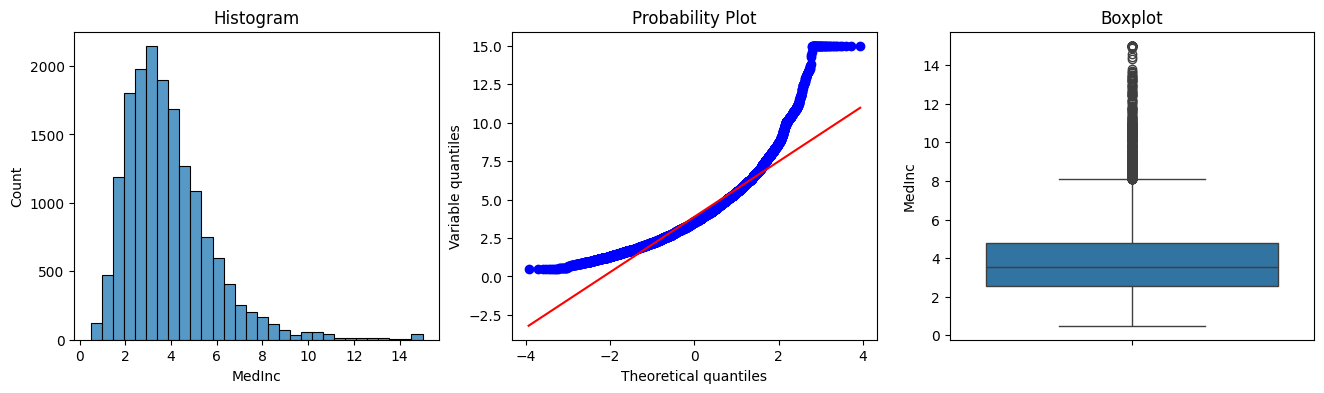

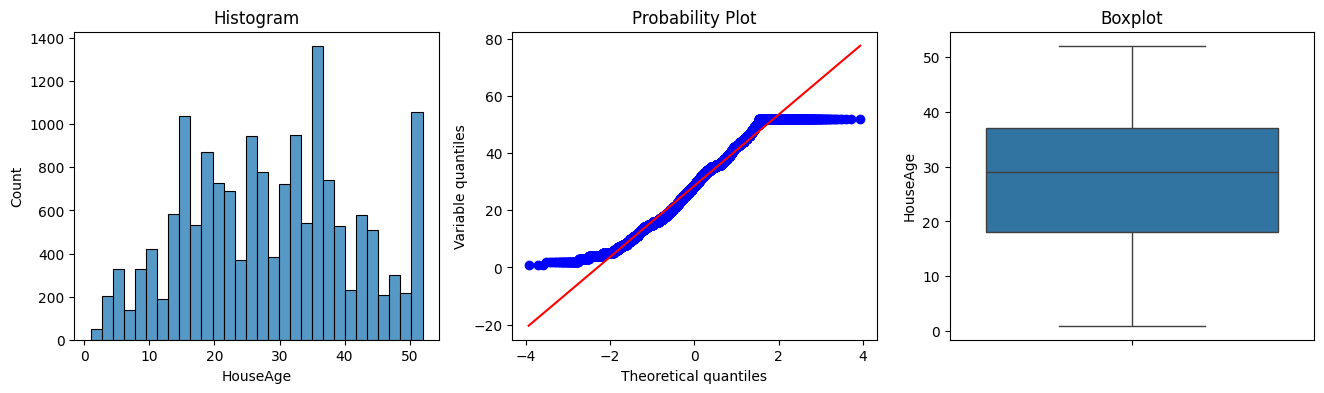

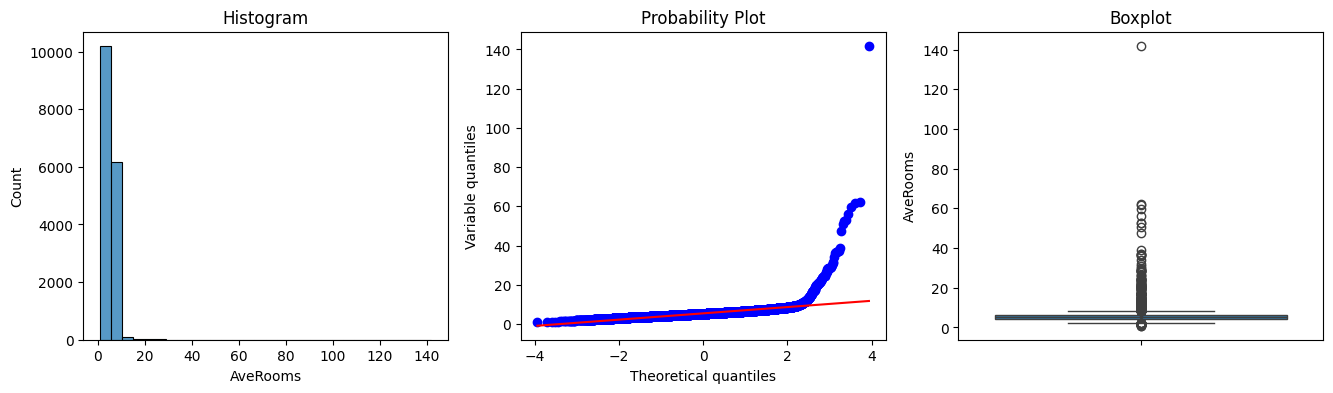

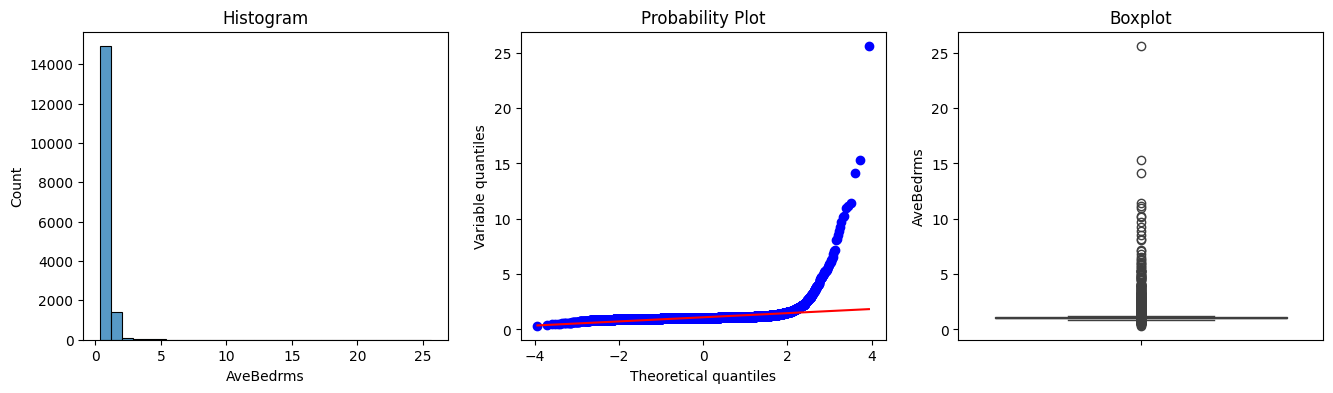

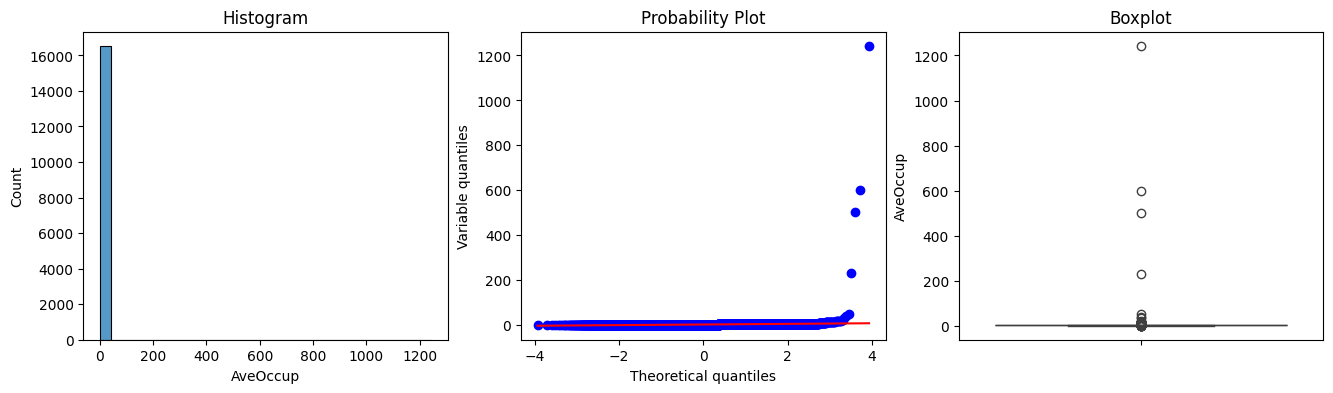

In [ ]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
for column in ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']:
    check_plot(train_clfr, column)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [ ]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [ ]:
MedInc_upper_limit, MedInc_lower_limit = find_outlier_boundary(train_clfr, 'MedInc')
MedInc_upper_limit, MedInc_lower_limit

(8.0828875, -0.7430125000000003)

In [ ]:
import numpy as np

In [ ]:
train_clfr['MedInc'] = np.where(
    train_clfr['MedInc'] > MedInc_upper_limit, MedInc_upper_limit,  # Jika lebih besar dari batas atas, ganti dengan batas atas
    np.where(
        train_clfr['MedInc'] < MedInc_lower_limit, MedInc_lower_limit,  # Jika lebih kecil dari batas bawah, ganti dengan batas bawah
        train_clfr['MedInc']  # Jika tidak outlier, biarkan tetap sama
    )
)

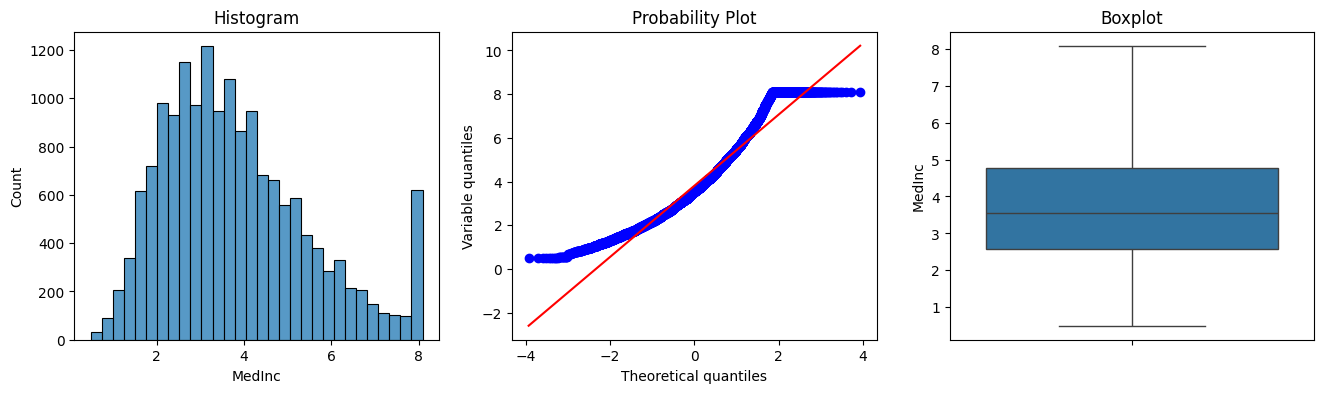

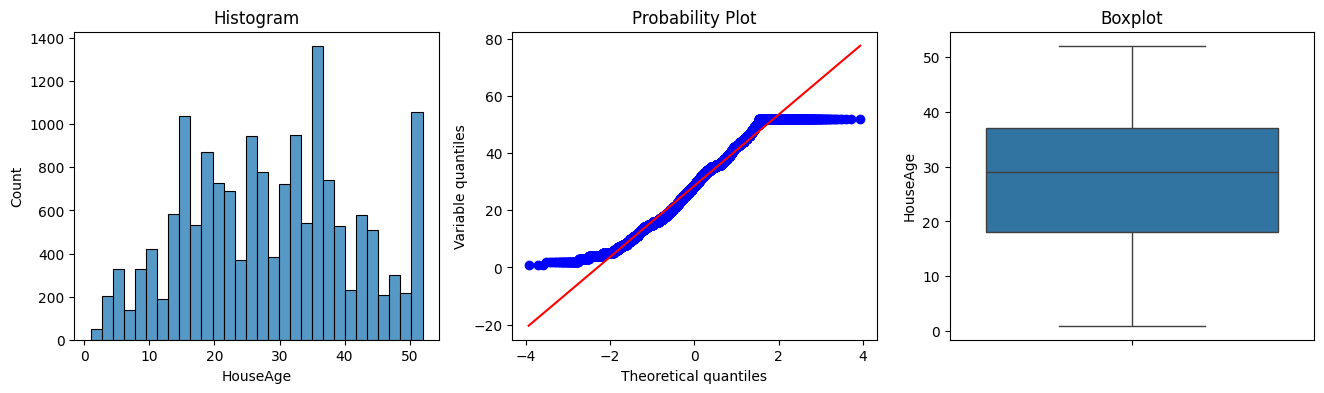

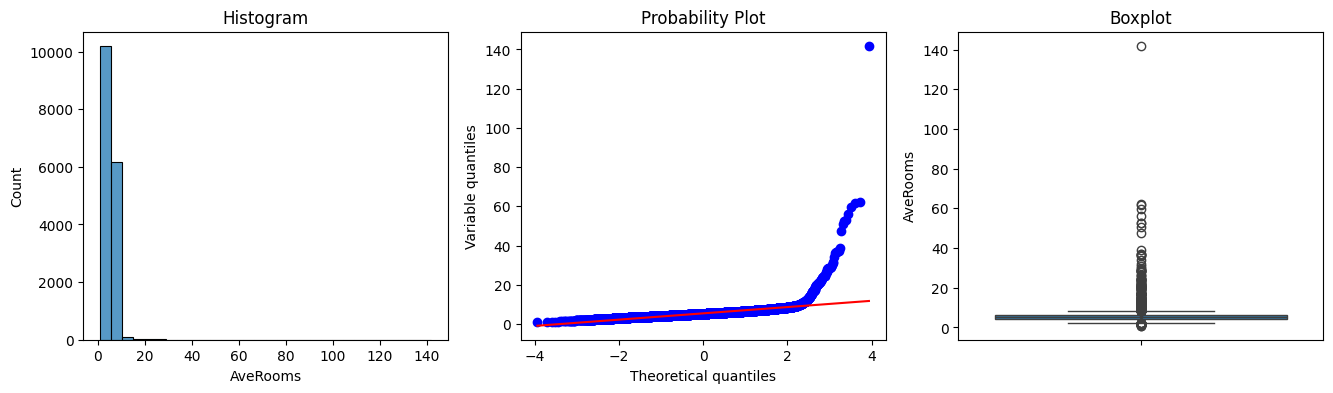

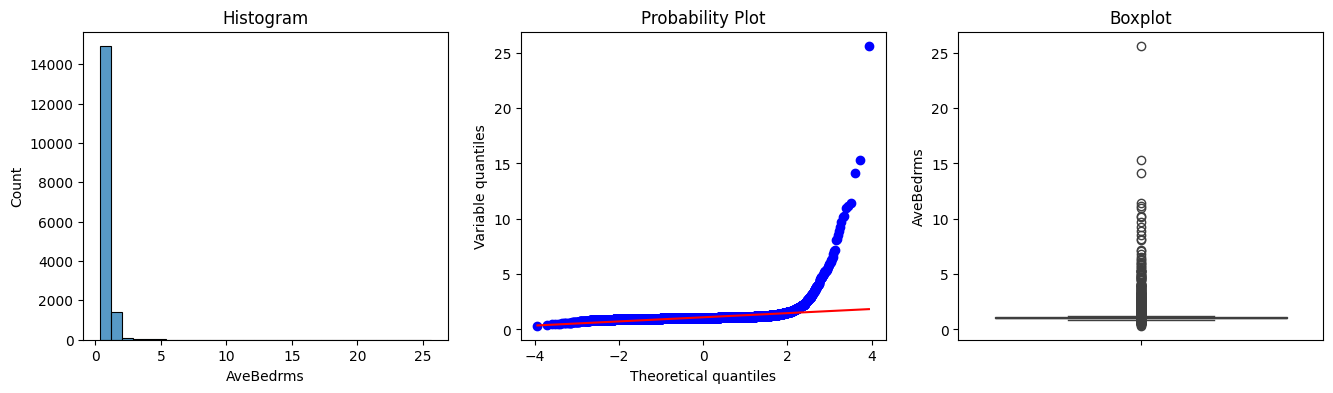

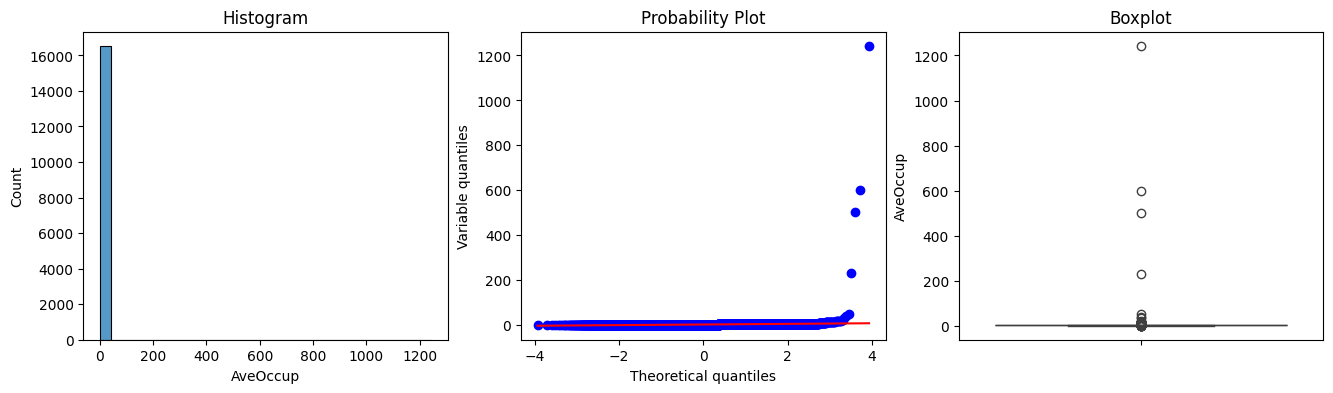

In [ ]:
# Melakukan loop untuk mengecek distribusi tiap kolom
for column in ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']:
    check_plot(train_clfr, column)

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [ ]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [ ]:
df_company.columns

Index(['Revenue', 'Size', 'Rating', 'Headquarters'], dtype='object')

In [ ]:
rating = 100 * len(df_company[df_company['Rating']==-1]) / len(df_company) #untuk menghitung persentase data dengan nilai Rating = -1 dalam dataset
size = 100 * len(df_company[df_company['Size'].isin(['-1','Unknown'])]) / len(df_company) #Menghitung persentase data yang kolom Size-nya bernilai '-1' atau 'Unknown'
revenue = 100 * len(df_company[df_company['Revenue'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company)

print(f"Persentase data dengan Rating = -1: {rating:.2f}%")
print(f"Persentase data dengan Size = '-1' atau 'Unknown': {size:.2f}%")
print(f"Persentase data dengan Revenue = '-1' atau 'Unknown / Non-Applicable': {revenue:.2f}%")

Persentase data dengan Rating = -1: 7.44%
Persentase data dengan Size = '-1' atau 'Unknown': 6.55%
Persentase data dengan Revenue = '-1' atau 'Unknown / Non-Applicable': 35.71%


In [ ]:
df_company = df_company.drop(columns=['Revenue'])
df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Size          672 non-null    object 
 1   Rating        672 non-null    float64
 2   Headquarters  672 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


In [ ]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size = 0.2, random_state=42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

In [ ]:
median_rating_train = train_company[train_company['Rating']!=-1]['Rating'].median()
print(f"Median Rating (tanpa outlier): {median_rating_train}")

Median Rating (tanpa outlier): 3.8


In [ ]:
train_company['Rating'] = train_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #train
test_company['Rating'] = test_company['Rating'].apply(lambda x: median_rating_train if x==-1 else x) #test

In [ ]:
train_company['Rating'].value_counts()

Rating
3.8    72
3.5    47
3.3    35
4.0    34
3.9    33
5.0    31
3.7    28
4.5    25
3.6    25
3.4    23
4.1    21
4.2    21
4.4    19
4.8    17
4.7    17
3.2    17
4.3    11
2.7    10
4.6    10
3.1     9
2.9     9
4.9     9
2.6     3
3.0     3
2.8     2
2.0     1
2.3     1
2.1     1
2.5     1
2.2     1
2.4     1
Name: count, dtype: int64

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
#Tulis jawaban missing value handling kolom Headquarters disini
persentase_headquarters = 100 * len(df_company[df_company['Headquarters'].isin(['-1','Unknown / Non-Applicable'])]) / len(df_company)
print("Persentase missing value: ", persentase_headquarters)
print("")
df_company.info()

Persentase missing value:  4.613095238095238

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Size          672 non-null    object 
 1   Rating        672 non-null    float64
 2   Headquarters  672 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


In [ ]:
#sebelum kita terapkan missing value handling, kita cek dulu bagian mana yang memiliki missing value pada kolom Headquarters
print(df_company[df_company["Headquarters"].isin(['-1', 'Unknown / Non-Applicable'])])

                  Size  Rating Headquarters
154                 -1    -1.0           -1
158                 -1    -1.0           -1
258            Unknown     5.0           -1
351                 -1    -1.0           -1
357                 -1    -1.0           -1
358                 -1    -1.0           -1
359                 -1    -1.0           -1
360                 -1    -1.0           -1
361                 -1    -1.0           -1
362                 -1    -1.0           -1
388                 -1    -1.0           -1
389                 -1    -1.0           -1
424            Unknown     3.4           -1
459                 -1    -1.0           -1
495                 -1    -1.0           -1
496                 -1    -1.0           -1
497                 -1    -1.0           -1
498                 -1    -1.0           -1
499                 -1    -1.0           -1
500                 -1    -1.0           -1
504  1 to 50 employees    -1.0           -1
519                 -1    -1.0  

Karena Headquarters type datanya adalah kategorial atau object maka handling yg digunakan adalah Modus

In [ ]:
modus_headquarters_train = train_company[train_company['Headquarters'] != -1]['Headquarters'].mode()[0]
print(f"Modus Headquarters: {modus_headquarters_train}")

Modus Headquarters: New York, NY


Replace missing value di headquarters dengan nilai modus_headquarters_train

In [ ]:
train_company['Headquarters'] = train_company['Headquarters'].replace("-1", modus_headquarters_train)
test_company['Headquarters'] = test_company['Headquarters'].replace("-1", modus_headquarters_train)
df_company['Headquarters'] = df_company['Headquarters'].replace("-1", modus_headquarters_train)

In [ ]:
#setelah proses handling missing value, kita cek kembali apakah masih ada data yang memiliki missing value
# pada kolom Headquarters

print("Train missing:", (train_company['Headquarters'] == "-1").sum())
print("Test missing:", (test_company['Headquarters'] == "-1").sum())
print(df_company[df_company["Headquarters"].isin(['-1', 'Unknown / Non-Applicable'])])

Train missing: 0
Test missing: 0
Empty DataFrame
Columns: [Size, Rating, Headquarters]
Index: []


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [ ]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
train_churn, test_churn = train_test_split(df_churn, test_size = 0.2, random_state=42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [ ]:
colom = ['StreamingMovies', 'StreamingTV', 'TechSupport',
               'DeviceProtection', 'OnlineBackup', 'OnlineSecurity',
               'MultipleLines']

In [ ]:
train_churn[colom] = train_churn[colom].replace('No internet service', 'No')
test_churn[colom] = test_churn[colom].replace('No internet service', 'No')

In [ ]:
for colom in colom:
    print(f"============= {column} =================")
    display(train_churn[colom].value_counts())
    print()

============= AveOccup =================


StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64


============= AveOccup =================


StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64


============= AveOccup =================


...

OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64


============= AveOccup =================


OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64


============= AveOccup =================


MultipleLines
No                  2685
Yes                 2397
No phone service     552
Name: count, dtype: int64

#LABEL ENCODER

In [ ]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# Kolom-kolom yang ingin di-label encode
columns_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport',
               'DeviceProtection', 'OnlineBackup', 'OnlineSecurity',
               'MultipleLines']

# Inisialisasi LabelEncoder
label_encoder = LabelEncoder()

In [ ]:
for col in columns_to_encode:
    train_churn[columns_to_encode] = label_encoder.fit_transform(train_churn[columns_to_encode])

In [ ]:
# Menerapkan label encoding yang sama ke data uji (test)
for col in columns_to_encode:
    test_churn[columns_to_encode] = label_encoder.transform(test_churn[columns_to_encode])

In [ ]:
train_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,0,1,21,Yes,No,DSL,Yes,No,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,No
1623,6035-RIIOM,Female,0,0,0,54,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,1,0,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,0,0,4,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,0,1,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


In [ ]:
test_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,1,0,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,0,0,41,Yes,Yes,No,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,1,1,52,Yes,No,No,No,No,No,No,No,No,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,0,0,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,0,0,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


## Selesai :)